<a href="https://colab.research.google.com/github/Hongdao-nn/Portfolio-Projects/blob/main/Customer-Shopping-Preferences-Project/Python/02_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# **Customer Segmentation & RFM Analysis - Clustering Insights**

##1. RFM Feature Engineering

**1.1. Loading and Basic Info**


**Objective:** Load and verify the integrity of the cleaned dataset from **Phase 1 (EDA).** This ensures that all features are correctly encoded and ready for the **RFM** (Recency, Frequency, Monetary) calculation.

**Key Actions:** Checking .info(), to ensure data integrity.

In [2]:
df = pd.read_csv("customer_shopping_cleaned.csv")
# Check the structure (number of rows, number of columns) and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   int64  
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   int64  
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   int64  
 14  Promo Code Used         3900 non-null   

**1.2. RFM Feature Engineering: Recency**

**Objective:**: Create a **Recency** metric to measure how recently a customer has made a purchase. Since the dataset does not provide specific transaction dates, we will derive this indicator from the `Frequency of Purchases` to estimate the time elapsed since the last interaction.

**Key Actions:**

* **Simulation Logic:** Assume a reference "current date" and subtract a calculated interval based on the purchase frequency. For example, a "Weekly" shopper is more likely to have a lower Recency score (more recent) than an "Annually" shopper.

* **Calculation:** Generate the `Recency`using a logical mapping or a controlled random distribution that aligns with the customer's shopping behavior.

* **Validation:** Ensure the new feature is numerical and ready for the scaling process.

In [3]:
# Define a mapping for 'Frequency of Purchases' to 'Recency' (days since last purchase)
# Lower recency values mean more recent purchases.
recency_mapping = {
    52.0: 7,    # Weekly purchases: ~7 days ago
    26.0: 14,   # Fortnightly/Bi-weekly purchases: ~14 days ago
    12.0: 30,   # Monthly purchases: ~30 days ago
    6.0: 60,    # Bi-monthly purchases: ~60 days ago (365/6)
    4.0: 90,    # Quarterly purchases: ~90 days ago
    1.0: 365    # Annually purchases: ~365 days ago
}

# Create the 'Recency' column using the defined mapping
df['Recency'] = df['Frequency of Purchases'].map(recency_mapping)

# Validate the new 'Recency' feature
# Check the first few rows with the new column
print("DataFrame with new 'Recency' column:")
display(df[['Frequency of Purchases', 'Recency']].head())

# Check data types and descriptive statistics for 'Recency'
print("\nInfo for 'Recency' column:")
df['Recency'].info()

print("\nDescriptive statistics for 'Recency' column:")
display(df['Recency'].describe())

DataFrame with new 'Recency' column:


,Frequency of Purchases,Recency
0,26.0,14
1,26.0,14
2,52.0,7
3,52.0,7
4,1.0,365



Info for 'Recency' column:
<class 'pandas.core.series.Series'>
RangeIndex: 3900 entries, 0 to 3899
Series name: Recency
Non-Null Count  Dtype
--------------  -----
3900 non-null   int64
dtypes: int64(1)
memory usage: 30.6 KB

Descriptive statistics for 'Recency' column:


,Recency
count,3900.000000
mean,89.133077
std,119.037566
min,7.000000
25%,14.000000
50%,30.000000
75%,90.000000
max,365.000000


**Results:**

* **Mapping Integrity:** The `Recency` column has been successfully generated for all **3,900 entries with 0 missing values.** This ensures total data consistency for the RFM model.

* **Mean Recency:** The **average** time since the last purchase is approximately **89 days.**

* **Median (50%):** Half of the customer base has interacted with the brand within the last **30 days**, indicating a relatively high level of recent engagement.

* **Range:** Values span from a minimum of 7 days (highly active) to a maximum of 365 days (at-risk/lapsed customers).


**1.2. RFM Feature Engineering: Frequency**

**Objective:** Extract and prepare the **Frequency (F)** component, which quantifies how often a customer completes a purchase within a defined period. This metric is a primary indicator of customer loyalty and habituation.

**Key Actions:**

* **Mapping:** Utilize the annualized frequency counts derived from the previous cleaning phase.

* **Analysis:** Review the distribution of purchase counts to understand the typical engagement level of the customer base.

In [4]:
# The 'Frequency of Purchases' column already represents the annualized frequency,
# which is suitable for the 'Frequency' component of RFM.
df['Frequency'] = df['Frequency of Purchases']

# Validate the new 'Frequency' feature
# Check the first few rows with the new column
print("DataFrame with new 'Frequency' column:")
display(df[['Frequency of Purchases', 'Frequency']].head())

# Check data types and descriptive statistics for 'Frequency'
print("\nInfo for 'Frequency' column:")
df['Frequency'].info()

print("\nDescriptive statistics for 'Frequency' column:")
display(df['Frequency'].describe())

DataFrame with new 'Frequency' column:


,Frequency of Purchases,Frequency
0,26.0,26.0
1,26.0,26.0
2,52.0,52.0
3,52.0,52.0
4,1.0,1.0



Info for 'Frequency' column:
<class 'pandas.core.series.Series'>
RangeIndex: 3900 entries, 0 to 3899
Series name: Frequency
Non-Null Count  Dtype  
--------------  -----  
3900 non-null   float64
dtypes: float64(1)
memory usage: 30.6 KB

Descriptive statistics for 'Frequency' column:


,Frequency
count,3900.000000
mean,17.471282
std,16.809646
min,1.000000
25%,4.000000
50%,12.000000
75%,26.000000
max,52.000000


**Results:**

* **Mapping Integrity:** The `Frequency` column has been successfully integrated for all **3,900 entries with 0 missing values**, providing a complete activity record for the RFM model.

* **Mean Frequency:** The **average** shopping frequency is approximately **17.47** purchases per year.

* **Median (50%):** Half of the customers shop at least **12 times a year** (once a month), indicating a solid base of regular consumers.

* **Range:** Values span from a minimum of 1 (annual shoppers) to a maximum of 52 (highly loyal weekly shoppers).

**1.3. RFM Feature Engineering: Monetary**

**Objective:** Prepare the **Monetary (M)** component, representing the total or average financial value a customer brings to the business. This helps in identifying high-value customers who contribute most to the revenue.

**Key Actions:**

* **Extraction:** Isolate the `Purchase Amount (USD)` for each customer record.

* **RFM Integration:** Consolidate **Recency**, **Frequency**, and **Monetary** into a single unified DataFrame (`rfm_df`) to prepare for the statistical scaling process.

In [5]:
# The 'Purchase Amount (USD)' column already represents the monetary value.
df['Monetary'] = df['Purchase Amount (USD)']

# Consolidate Recency, Frequency, and Monetary into a single DataFrame
rfm_df = df[['Customer ID', 'Recency', 'Frequency', 'Monetary']].copy()

# Validate the new 'rfm_df' DataFrame
print("RFM DataFrame head:")
display(rfm_df.head())

print("\nRFM DataFrame info:")
rfm_df.info()

print("\nRFM DataFrame descriptive statistics:")
display(rfm_df.describe())

RFM DataFrame head:


,Customer ID,Recency,Frequency,Monetary
0,1,14,26.0,53
1,2,14,26.0,64
2,3,7,52.0,73
3,4,7,52.0,90
4,5,365,1.0,49



RFM DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer ID  3900 non-null   int64  
 1   Recency      3900 non-null   int64  
 2   Frequency    3900 non-null   float64
 3   Monetary     3900 non-null   int64  
dtypes: float64(1), int64(3)
memory usage: 122.0 KB

RFM DataFrame descriptive statistics:


,Customer ID,Recency,Frequency,Monetary
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,89.133077,17.471282,59.764359
std,1125.977353,119.037566,16.809646,23.685392
min,1.000000,7.000000,1.000000,20.000000
25%,975.750000,14.000000,4.000000,39.000000
50%,1950.500000,30.000000,12.000000,60.000000
75%,2925.250000,90.000000,26.000000,81.000000
max,3900.000000,365.000000,52.000000,100.000000


**Results:**

* **Mapping Integrity:** The `Monetary` column (extracted from `Purchase Amount (USD)`) has been successfully integrated for all **3,900 entries with 0 missing values**, ensuring a stable revenue baseline.

* **Mean Monetary:** The **average** purchase value per transaction is approximately **$59.76.**

* **Median (50%):** Half of the customer transactions are valued at **$60.00 or more**, showing a very consistent spending pattern across the board.

* **Range:** Values span from a minimum of **\$20.00** (budget-conscious) to a maximum of **\$100.00** (premium purchases).

## 2. Data Scaling

**Objective:** Standardize the **RFM** features to ensure they are on a comparable scale. Since K-Means relies on Euclidean distance, scaling prevents variables with larger magnitudes (like Recency) from dominating the clustering process.

**Key Actions:**

* **Feature Selection:** Isolate the numerical RFM columns, excluding the `Customer ID.`

* **Standardization:** Apply **StandardScaler** to transform the data so that each feature has a Mean of 0 and a Standard Deviation of 1.

* **Verification:** Audit the scaled distribution to confirm the transformation was successful before proceeding to clustering.

In [11]:
# Isolate the RFM features for scaling (excluding 'Customer ID')
rfm_features = rfm_df[['Recency', 'Frequency', 'Monetary']]

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the RFM features
rfm_scaled = scaler.fit_transform(rfm_features)

# Create a DataFrame with the scaled features
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency_Scaled', 'Frequency_Scaled', 'Monetary_Scaled'])

# Display the head of the scaled DataFrame
print("Scaled RFM DataFrame head:")
display(rfm_scaled_df.head())

# Display descriptive statistics to verify scaling (mean should be close to 0, std dev close to 1)
print("\nDescriptive statistics for scaled RFM features:")
display(rfm_scaled_df[['Recency_Scaled', 'Frequency_Scaled', 'Monetary_Scaled']].describe())

Scaled RFM DataFrame head:


,Recency_Scaled,Frequency_Scaled,Monetary_Scaled
0,-0.631252,0.507436,-0.285629
1,-0.631252,0.507436,0.178852
2,-0.690065,2.054365,0.558882
3,-0.690065,2.054365,1.276716
4,2.317775,-0.979997,-0.454531



Descriptive statistics for scaled RFM features:


,Recency_Scaled,Frequency_Scaled,Monetary_Scaled
count,3.900000e+03,3.900000e+03,3.900000e+03
mean,-4.645856e-17,-8.745141e-17,-1.166019e-16
std,1.000128e+00,1.000128e+00,1.000128e+00
min,-6.900646e-01,-9.799965e-01,-1.679071e+00
25%,-6.312521e-01,-8.015047e-01,-8.767861e-01
50%,-4.968235e-01,-3.255264e-01,9.950067e-03
75%,7.283703e-03,5.074355e-01,8.966862e-01
max,2.317775e+00,2.054365e+00,1.698971e+00


**Results:**

*   **Scaling Success:** The `Recency`, `Frequency`, and `Monetary` features have been successfully scaled using `StandardScaler`. Their means are now centered around 0, and their standard deviations are approximately 1.

*   **Impact on Clustering:** This standardization ensures that all features contribute equally to the distance calculations in clustering algorithms, preventing any single feature from dominating due to its larger magnitude.

* **Distribution Audit:**

**Recency_Scaled Range:** Spans from **-0.69 to 2.32.**

**Frequency_Scaled Range:** Spans from **-0.98 to 2.05.**

**Monetary_Scaled Range:** Spans from **-1.68 to 1.70.**

*   **Prepared for Analysis:** The `rfm_scaled_df` is now ready for further analysis, specifically for determining the optimal number of clusters and applying clustering algorithms.

## 3. K-Means Clustering

**3.1. Finding Optimal K (Elbow Method)**

**Objective:** Determine the ideal number of customer segments by analyzing the **WCSS** (Within-Cluster Sum of Squares). We want to find the **elbow point** where adding more clusters no longer significantly improves the model's compactness.

**Key Actions:**

* **Iterative Testing:** Run the K-Means algorithm for a range of clusters (typically $k=1$ to $k=10$).

* **Visualization:** Plot the WCSS values to identify the elbow point.

* **Selection:** Choose the optimal $k$ that balances model complexity and segment clarity.

WCSS values for K from 1 to 10:
K=1: 11700.00
K=2: 7455.06
K=3: 4942.12
K=4: 3000.08
K=5: 2421.33
K=6: 1933.15
K=7: 1488.73
K=8: 1127.50
K=9: 905.20
K=10: 745.68


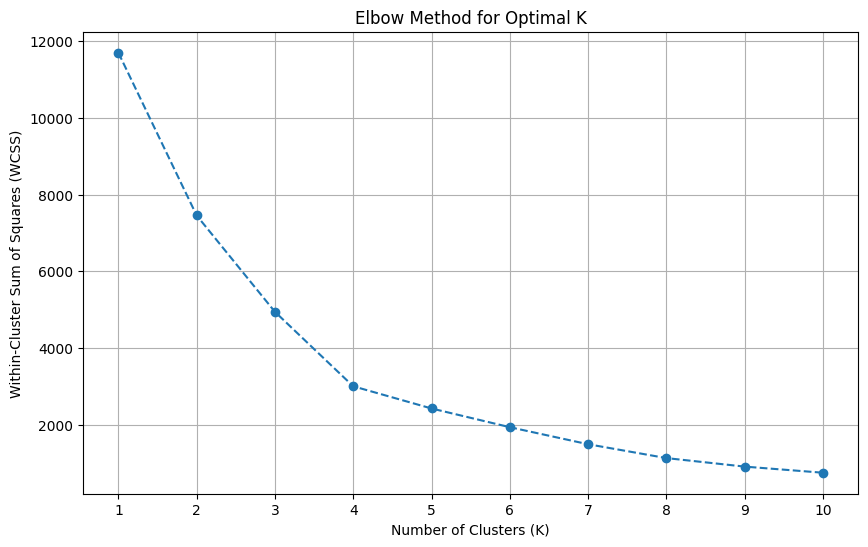

In [16]:
# Initialize a list to store WCSS values
wcss = []

# Define the range of clusters to test
k_range = range(1, 11) # Test from 1 to 10 clusters

# Loop through the range of k values
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df[['Recency_Scaled', 'Frequency_Scaled', 'Monetary_Scaled']])
    wcss.append(kmeans.inertia_)

# Print WCSS values
print("WCSS values for K from 1 to 10:")
for i, w in enumerate(wcss):
    print(f"K={k_range[i]}: {w:.2f}")

# Plot the WCSS values
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

**Results:**

* **WCSS Trend:** We observe a sharp decline in WCSS from $K=1$ ($11,700.00$) to $K=4$ ($3,000.08$).

* **The "Elbow" Point:** The rate of decrease significantly slows down after $K=4$. Moving from $K=4$ to $K=5$ only reduces WCSS by about $578$ units, compared to the drop of nearly $1,942$ units when moving from $K=3$ to $K=4$.

* **Conclusion:** $K=4$ is the optimal choice. It represents the elbow of the curve, providing enough complexity to capture distinct customer behaviors while maintaining a model that is easy for the business to interpret.